In [1]:
# Install required packages (if not already installed)
!pip uninstall -y tensorflow keras pennylane imbalanced-learn
!pip install tensorflow==2.15.0 keras==2.15.0 pennylane==0.39 imbalanced-learn tf-explain

# Standard imports
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Quantum imports
import pennylane as qml
from tf_explain.core.grad_cam import GradCAM

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Found existing installation: keras 3.5.0
Uninstalling keras-3.5.0:
  Successfully uninstalled keras-3.5.0
Found existing installation: imbalanced-learn 0.12.4
Uninstalling imbalanced-learn-0.12.4:
  Successfully uninstalled imbalanced-learn-0.12.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.7 MB

**2. Set Random Seeds for Reproducibility*# ***

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

3. Prepare the Dataset

In [3]:
# Define dataset paths and class information
base_dataset_path = "/kaggle/input/oral-diseases"  # Adjust if needed
class_names = [
    "Calculus",
    "Data caries",
    "Gingivitis",
    "Mouth Ulcer",
    "ToothDiscoloration",
    "Hypodentia"
]
num_classes = len(class_names)

cls_folder_map = {
    "Calculus": "Calculus/Calculus",
    "Data caries": "Data caries/Data caries/caries orignal data set/done",
    "Gingivitis": "Gingivitis/Gingivitis",
    "Mouth Ulcer": "Mouth Ulcer/Mouth Ulcer/ulcer original dataset/ulcer original dataset",
    "ToothDiscoloration": "Tooth Discoloration/Tooth Discoloration /tooth discoloration original dataset/tooth discoloration original dataset",
    "Hypodentia": "hypodontia/hypodontia"
}

working_dir = "/kaggle/working/"
dataset_dir = os.path.join(working_dir, "dataset")
os.makedirs(dataset_dir, exist_ok=True)

# Copy folders into a local dataset directory
for cls in class_names:
    src = os.path.join(base_dataset_path, cls_folder_map[cls])
    dst = os.path.join(dataset_dir, cls)
    shutil.copytree(src, dst, dirs_exist_ok=True)
print("All classes copied into local 'dataset' folder!")

# Create train, validation, and test directories
train_dir = os.path.join(working_dir, "train")
val_dir   = os.path.join(working_dir, "val")
test_dir  = os.path.join(working_dir, "test")
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)
    for cls in class_names:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# Split each class into 70% train, 15% validation, and 15% test
for cls in class_names:
    class_path = os.path.join(dataset_dir, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    n_total = len(images)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    train_files = images[:n_train]
    val_files   = images[n_train:n_train + n_val]
    test_files  = images[n_train + n_val:]
    
    for f in train_files:
        shutil.move(os.path.join(class_path, f), os.path.join(train_dir, cls, f))
    for f in val_files:
        shutil.move(os.path.join(class_path, f), os.path.join(val_dir, cls, f))
    for f in test_files:
        shutil.move(os.path.join(class_path, f), os.path.join(test_dir, cls, f))
print("Train/Val/Test split completed!")


All classes copied into local 'dataset' folder!
Train/Val/Test split completed!


In [4]:
image_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 3892 images belonging to 6 classes.
Found 831 images belonging to 6 classes.
Found 840 images belonging to 6 classes.


In [5]:
# Quantum circuit parameters
num_qubits = 6
num_layers = 6  # Number of entanglement repetitions
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev, interface='tf', batching=True)
def quantum_circuit(inputs, weights):
    # Apply Hadamard gates to each qubit (batched)
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
    # Embed classical data using RY gates
    for i in range(num_qubits):
        qml.RY(inputs[:, i], wires=i)
    # Entanglement layers with parameterized rotations
    for layer in range(num_layers):
        # RY rotations
        for i in range(num_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
        # Entanglement using CZ gates
        for i in range(num_qubits - 1):
            qml.CZ(wires=[i, i + 1])
        qml.CZ(wires=[num_qubits - 1, 0])
        # RZ rotations
        for i in range(num_qubits):
            qml.RZ(weights[layer, i, 1], wires=i)
    # Final rotation and measurement preparation
    for i in range(num_qubits):
        qml.RX(weights[num_layers, i, 0], wires=i)
        qml.Hadamard(wires=i)
    # Return expectation values for each qubit (batched)
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

# Define weight shapes to accommodate layers + final rotation parameters
weight_shapes = {"weights": (num_layers + 1, num_qubits, 2)}
quantum_layer = qml.qnn.KerasLayer(
    quantum_circuit, 
    weight_shapes, 
    output_dim=num_qubits,
    name="quantum_layer"
)

/usr/local/lib/python3.10/dist-packages/pennylane/workflow/qnode.py:148: UserWarning: Received gradient_kwarg batching, which is not included in the list of standard qnode gradient kwargs.
  warnings.warn(


In [6]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Load EfficientNetB3 as the backbone
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
# Freeze the base model if needed (optional):
# for layer in base_model.layers:
#    layer.trainable = False

# Create a custom feature extractor head
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Match the number of features to the number of qubits using tanh activation
x = Dense(num_qubits, activation='tanh', name="pre_quantum_dense")(x)

43941136/43941136 [==============================] - 0s 0us/step


In [7]:
# Pass features through the quantum layer
x = quantum_layer(x)
# Final classification layer
outputs = Dense(num_classes, activation="softmax")(x)

# Build the final model
model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile the model with an optimizer, loss, and metrics
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# Display model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0][0]']   

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=100,  # Adjust epochs as needed
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
122/122 [==============================] - ETA: 0s - loss: 1.4175 - accuracy: 0.6048
Epoch 1: val_loss improved from inf to 1.61019, saving model to best_model.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


122/122 [==============================] - 344s 2s/step - loss: 1.4175 - accuracy: 0.6048 - val_loss: 1.6102 - val_accuracy: 0.4260 - lr: 1.0000e-04
Epoch 2/100
122/122 [==============================] - ETA: 0s - loss: 1.2486 - accuracy: 0.7279
Epoch 2: val_loss did not improve from 1.61019
122/122 [==============================] - 299s 2s/step - loss: 1.2486 - accuracy: 0.7279 - val_loss: 1.6491 - val_accuracy: 0.4007 - lr: 1.0000e-04
Epoch 3/100
122/122 [==============================] - ETA: 0s - loss: 1.1616 - accuracy: 0.7700
Epoch 3: val_loss improved from 1.61019 to 1.32096, saving model to best_model.h5
122/122 [==============================] - 300s 2s/step - loss: 1.1616 - accuracy: 0.7700 - val_loss: 1.3210 - val_accuracy: 0.6378 - lr: 1.0000e-04
Epoch 4/100
122/122 [==============================] - ETA: 0s - loss: 1.0978 - accuracy: 0.7901
Epoch 4: val_loss did not improve from 1.32096
122/122 [==============================] - 294s 2s/step - loss: 1.0978 - accuracy: 0.7

27/27 [==============================] - 18s 656ms/step - loss: 0.5474 - accuracy: 0.8369
Test Loss: 0.5474, Test Accuracy: 0.8369
27/27 [==============================] - 17s 642ms/step


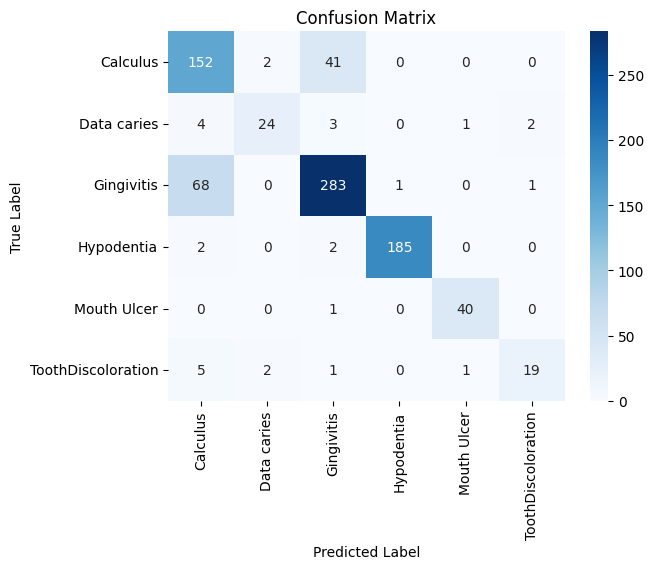

Classification Report:
                    precision    recall  f1-score   support

          Calculus       0.66      0.78      0.71       195
       Data caries       0.86      0.71      0.77        34
        Gingivitis       0.85      0.80      0.83       353
        Hypodentia       0.99      0.98      0.99       189
       Mouth Ulcer       0.95      0.98      0.96        41
ToothDiscoloration       0.86      0.68      0.76        28

          accuracy                           0.84       840
         macro avg       0.86      0.82      0.84       840
      weighted avg       0.85      0.84      0.84       840



In [9]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Generate predictions and compute evaluation metrics
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names_list = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = sns.heatmap(
    tf.math.confusion_matrix(y_true, y_pred).numpy(),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names_list, yticklabels=class_names_list
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names_list))

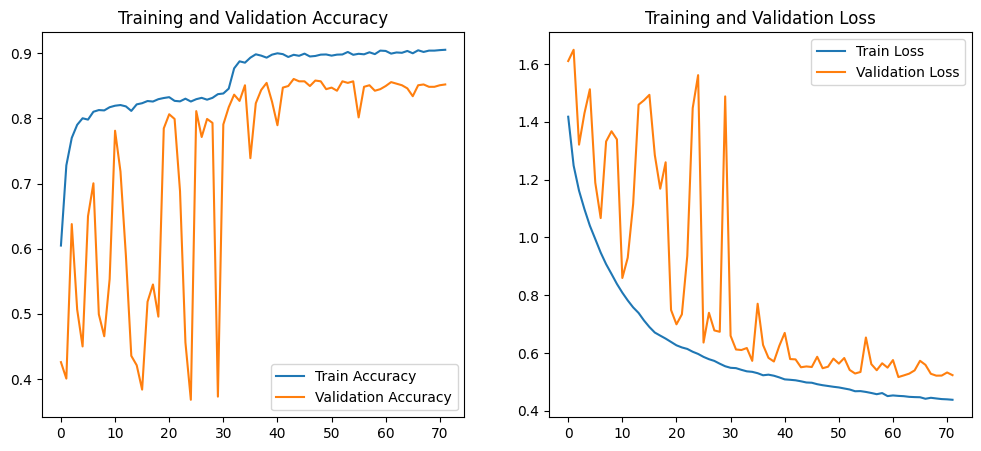

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

27/27 [==============================] - 18s 659ms/step


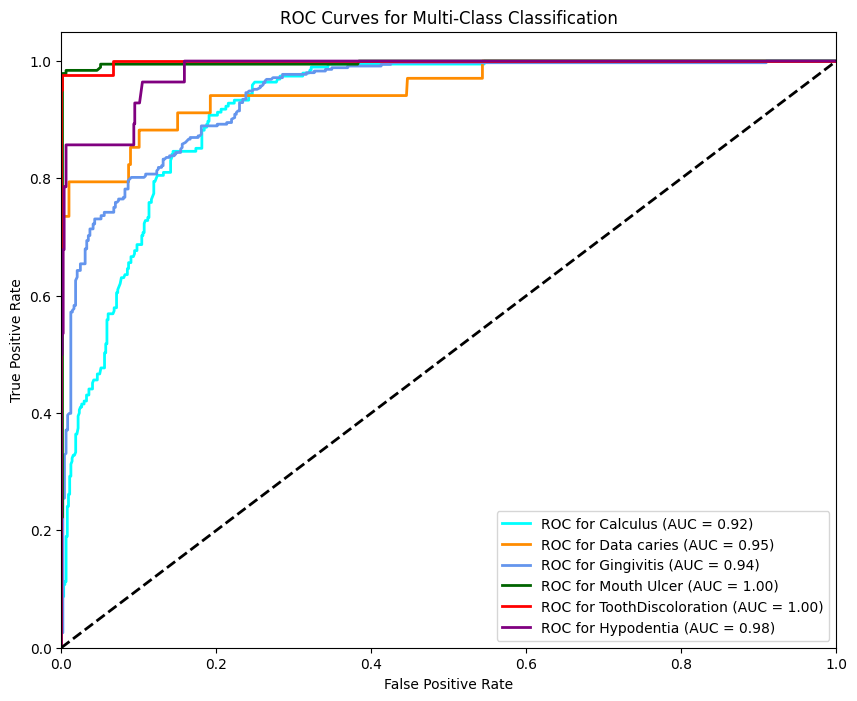

Macro-average ROC AUC: 0.97
27/27 [==============================] - 6s 126ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


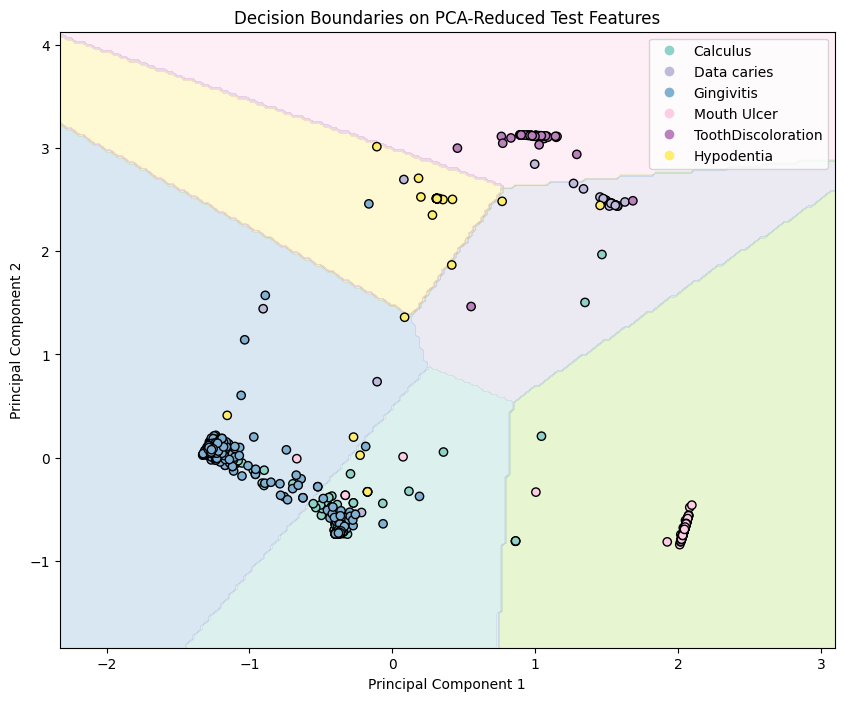

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ------------------------------
# 1. ROC AUC Evaluation
# ------------------------------

# Assuming your model is already trained and is named "model"
# and your test_generator is ready with shuffle=False for consistency.

# Reset the test generator in case you need to start predictions at the beginning.
test_generator.reset()

# Obtain predicted probabilities on test data
y_pred = model.predict(test_generator, verbose=1)
# True labels (as integers corresponding to class indices)
y_true = test_generator.classes
# Since multi-class, we convert true labels to one-hot encoding.
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Compute ROC Curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'red', 'purple']
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f'ROC for {class_names[i]} (AUC = {roc_auc[i]:0.2f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multi-Class Classification")
plt.legend(loc="lower right")
plt.show()

# Optionally, compute the overall AUC (for example, macro-average)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)
print(f"Macro-average ROC AUC: {macro_auc:0.2f}")


# ------------------------------
# 2. Visualizing Decision Boundaries via PCA
# ------------------------------

# Note:
# Directly plotting decision boundaries in high-dimensional spaces is impractical.
# Instead, we extract features from an intermediate layer (e.g., the "pre_quantum_dense" layer),
# reduce their dimension with PCA to 2D, and then train a surrogate classifier (here, logistic regression)
# to approximate the decision boundary for visualization.

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Build an intermediate model to extract features.
# Make sure you use the layer name right where you want to tap into the model.
feature_extractor = tf.keras.models.Model(inputs=model.input,
                                          outputs=model.get_layer("pre_quantum_dense").output)

# Extract features from the test set (or a subset that fits into memory)
features = feature_extractor.predict(test_generator, verbose=1)

# Apply PCA to reduce dimensions to 2 for visualization.
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

# For the decision boundaries, we are using the true class labels from the test set.
# (They should be in the same order as the features due to the use of reset() above.)
labels = test_generator.classes

# Train a simple classifier on the 2D features.
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
clf.fit(features_2d, labels)

# Create a meshgrid based on the 2D PCA space.
x_min, x_max = features_2d[:, 0].min() - 1, features_2d[:, 0].max() + 1
y_min, y_max = features_2d[:, 1].min() - 1, features_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict the class for each point in the meshgrid.
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries along with the test features.
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, 
                      edgecolor='k', cmap=plt.cm.Set3)
plt.title("Decision Boundaries on PCA-Reduced Test Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)
plt.show()

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

# Reset the test generator for consistent ordering if necessary
test_generator.reset()

# Generate predictions on the test set
y_pred = model.predict(test_generator, verbose=1)

# True labels (as integers corresponding to class indices)
y_true = test_generator.classes

# Binarize the true labels for multi-class ROC computation
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Compute ROC curve datapoints for each class and save to CSV
for i, cls_name in enumerate(class_names):
    # Compute false positive rate (fpr) and true positive rate (tpr)
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    
    # Create a DataFrame with fpr and tpr
    df_roc = pd.DataFrame({'FPR': fpr, 'TPR': tpr})
    
    # Save CSV file for this class
    csv_filename = f"roc_curve_{cls_name.replace(' ', '_')}.csv"
    df_roc.to_csv(csv_filename, index=False)
    
    print(f"ROC curve datapoints for {cls_name} saved in '{csv_filename}'")

27/27 [==============================] - 18s 668ms/step
ROC curve datapoints for Calculus saved in 'roc_curve_Calculus.csv'
ROC curve datapoints for Data caries saved in 'roc_curve_Data_caries.csv'
ROC curve datapoints for Gingivitis saved in 'roc_curve_Gingivitis.csv'
ROC curve datapoints for Mouth Ulcer saved in 'roc_curve_Mouth_Ulcer.csv'
ROC curve datapoints for ToothDiscoloration saved in 'roc_curve_ToothDiscoloration.csv'
ROC curve datapoints for Hypodentia saved in 'roc_curve_Hypodentia.csv'


27/27 [==============================] - 18s 667ms/step


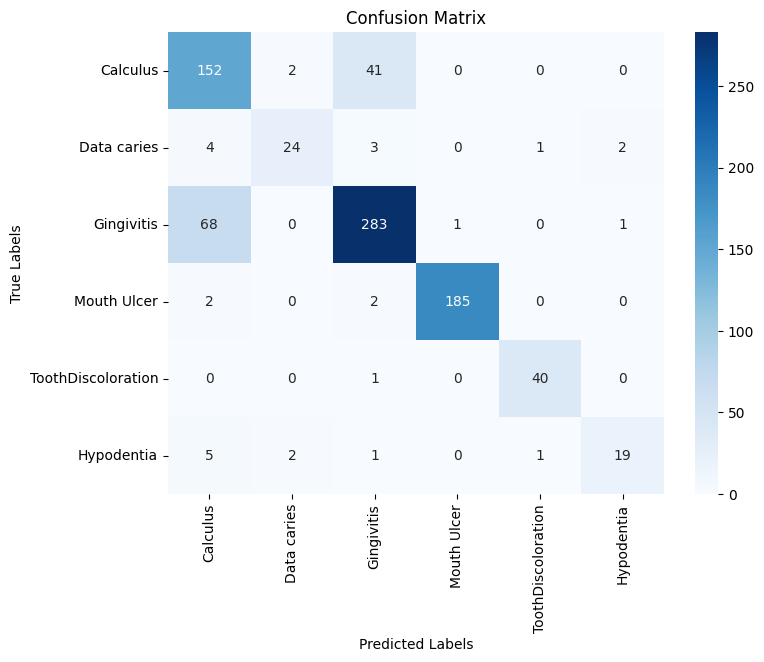

Common Misclassification Patterns:
            True Label     Predicted Label  Count
6           Gingivitis            Calculus     68
1             Calculus          Gingivitis     41
9           Hypodentia            Calculus      5
2          Data caries            Calculus      4
3          Data caries          Gingivitis      3
0             Calculus         Data caries      2
10          Hypodentia         Data caries      2
4          Data caries          Hypodentia      2
14         Mouth Ulcer          Gingivitis      2
13         Mouth Ulcer            Calculus      2
7           Gingivitis          Hypodentia      1
5          Data caries  ToothDiscoloration      1
11          Hypodentia          Gingivitis      1
8           Gingivitis         Mouth Ulcer      1
12          Hypodentia  ToothDiscoloration      1
15  ToothDiscoloration          Gingivitis      1
Misclassification patterns saved to 'misclassification_patterns.csv'.

Edge Cases based on Confidence Gap:
    Inde

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Ensure the test generator starts at the beginning of the dataset
test_generator.reset()

# -------------------------------
# 1. Generate Predictions & Confusion Matrix
# -------------------------------

# Get predicted probabilities and true labels
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# 2. Identify Common Misclassification Patterns
# -------------------------------

# Get indices where predictions are incorrect
error_indices = np.where(y_true != y_pred)[0]

# Create a DataFrame of misclassified samples with their true and predicted labels
misclassifications = pd.DataFrame({
    'Index': error_indices,
    'True Label': [class_names[y_true[i]] for i in error_indices],
    'Predicted Label': [class_names[y_pred[i]] for i in error_indices]
})

# Count how often each misclassification pattern occurs
misclassification_counts = misclassifications.groupby(
    ['True Label', 'Predicted Label']
).size().reset_index(name='Count').sort_values(by='Count', ascending=False)

print("Common Misclassification Patterns:")
print(misclassification_counts)

# Save misclassification patterns to CSV for documentation
misclassification_counts.to_csv("misclassification_patterns.csv", index=False)
print("Misclassification patterns saved to 'misclassification_patterns.csv'.")

# -------------------------------
# 3. Document Edge Cases
# -------------------------------

# Define an edge case based on low confidence: 
# For example, if the gap between the highest and the second highest predicted probability is below a threshold,
# it might be an ambiguous case. Adjust the threshold as appropriate.
confidence_threshold = 0.1
edge_case_indices = []

# Loop through each prediction and evaluate the confidence gap
for i in range(len(y_pred_probs)):
    sorted_probs = np.sort(y_pred_probs[i])
    confidence_gap = sorted_probs[-1] - sorted_probs[-2]
    if confidence_gap < confidence_threshold and y_true[i] != y_pred[i]:
        edge_case_indices.append(i)

# Document these edge cases into a DataFrame
edge_cases = pd.DataFrame({
    'Index': edge_case_indices,
    'True Label': [class_names[y_true[i]] for i in edge_case_indices],
    'Predicted Label': [class_names[y_pred[i]] for i in edge_case_indices],
    'Confidence Gap': [np.sort(y_pred_probs[i])[-1] - np.sort(y_pred_probs[i])[-2] for i in edge_case_indices]
})

print("\nEdge Cases based on Confidence Gap:")
print(edge_cases)

# Save edge cases details to CSV for further analysis or documentation
edge_cases.to_csv("edge_cases.csv", index=False)
print("Edge cases have been saved to 'edge_cases.csv'.")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model
import pennylane as qml

# Helper function: Build a hybrid model with configurable quantum circuit depth and optional modifications.
def build_hybrid_model(num_quantum_layers=6, include_quantum_layer=True, include_classical_head=True):
    image_size = (224, 224)
    num_classes = len(class_names)
    num_qubits = 6  # Fixed for our design

    # Define a configurable quantum circuit.
    dev = qml.device("default.qubit", wires=num_qubits)
    
    # Define the quantum circuit using the depth parameter
    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply Hadamard gates to all qubits
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Data embedding using RY rotations (assuming inputs shape [batch, num_qubits])
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Configurable entanglement layers based on num_quantum_layers
        for layer in range(num_quantum_layers):
            # Add RY rotation with learnable parameters
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            # Entanglement with CZ gates (ring topology)
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i + 1])
            qml.CZ(wires=[num_qubits - 1, 0])
            # Add RZ rotations with learnable parameters
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final rotations and Hadamard gate for measurement preparation
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        # Return expectation values for each qubit as output features
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    # Adjust the weight shape based on num_quantum_layers
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    
    # Optionally include the quantum layer
    if include_quantum_layer:
        quantum_layer = qml.qnn.KerasLayer(
            quantum_circuit, 
            weight_shapes, 
            output_dim=num_qubits,
            name="quantum_layer"
        )
    
    # Build the classical backbone model
    backbone = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(image_size[0], image_size[1], 3))
    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    
    # Optionally include a dense layer to match the number of qubits
    if include_classical_head:
        x = Dense(num_qubits, activation="tanh", name="pre_quantum_dense")(x)
    
    # Connect to quantum layer if enabled
    if include_quantum_layer:
        x = quantum_layer(x)
    
    # Final classification layer
    output = Dense(num_classes, activation="softmax", name="output")(x)
    
    model = Model(inputs=backbone.input, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Example: Run ablation study for different circuit depths.
ablation_results = {}
for depth in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
    print(f"\nTraining model with quantum circuit depth = {depth}")
    model_variant = build_hybrid_model(num_quantum_layers=depth)
    # You can either train the model or evaluate on validation data
    history = model_variant.fit(train_generator, epochs=10, validation_data=val_generator, verbose=1)
    val_loss, val_acc = model_variant.evaluate(val_generator, verbose=0)
    ablation_results[f"Depth_{depth}"] = {"val_loss": val_loss, "val_accuracy": val_acc}

print("\nAblation study results:")
for config, metrics in ablation_results.items():
    print(f"{config}: Loss = {metrics['val_loss']:0.4f}, Accuracy = {metrics['val_accuracy']:0.4f}")


Training model with quantum circuit depth = 1
Epoch 1/10
122/122 [==============================] - 259s 2s/step - loss: 1.4802 - accuracy: 0.5131 - val_loss: 1.9783 - val_accuracy: 0.2250
Epoch 2/10
122/122 [==============================] - 225s 2s/step - loss: 1.2069 - accuracy: 0.6650 - val_loss: 1.9224 - val_accuracy: 0.2250
Epoch 3/10
122/122 [==============================] - 225s 2s/step - loss: 1.1008 - accuracy: 0.6557 - val_loss: 1.7383 - val_accuracy: 0.2250
Epoch 4/10
122/122 [==============================] - 225s 2s/step - loss: 1.0363 - accuracy: 0.6603 - val_loss: 1.6597 - val_accuracy: 0.2335
Epoch 5/10
122/122 [==============================] - 223s 2s/step - loss: 1.0227 - accuracy: 0.6498 - val_loss: 1.9602 - val_accuracy: 0.0481
Epoch 6/10
122/122 [==============================] - 226s 2s/step - loss: 0.9688 - accuracy: 0.6616 - val_loss: 2.0595 - val_accuracy: 0.0469
Epoch 7/10
122/122 [==============================] - 223s 2s/step - loss: 0.9209 - accuracy: 0

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
from IPython.display import FileLink, display

# Reset the test generator for consistent ordering
test_generator.reset()

# Generate predictions on the test set
y_pred = model.predict(test_generator, verbose=1)

# True labels (as integers corresponding to class indices)
y_true = test_generator.classes

# Binarize the true labels for multi-class ROC computation
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Compute ROC curve datapoints for each class and save to CSV
for i, cls_name in enumerate(class_names):
    # Compute false positive rate (fpr) and true positive rate (tpr)
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    
    # Create a DataFrame with fpr and tpr
    df_roc = pd.DataFrame({'FPR': fpr, 'TPR': tpr})
    
    # Save CSV file for this class
    csv_filename = f"roc_curve_{cls_name.replace(' ', '_')}.csv"
    df_roc.to_csv(csv_filename, index=False)
    
    print(f"ROC curve datapoints for {cls_name} saved in '{csv_filename}'")
    
    # Display a clickable download link for each CSV file
    display(FileLink(csv_filename))

27/27 [==============================] - 18s 657ms/step
ROC curve datapoints for Calculus saved in 'roc_curve_Calculus.csv'


/kaggle/working/roc_curve_Calculus.csv

ROC curve datapoints for Data caries saved in 'roc_curve_Data_caries.csv'


/kaggle/working/roc_curve_Data_caries.csv

ROC curve datapoints for Gingivitis saved in 'roc_curve_Gingivitis.csv'


...

/kaggle/working/roc_curve_Mouth_Ulcer.csv

ROC curve datapoints for ToothDiscoloration saved in 'roc_curve_ToothDiscoloration.csv'


/kaggle/working/roc_curve_ToothDiscoloration.csv

ROC curve datapoints for Hypodentia saved in 'roc_curve_Hypodentia.csv'


/kaggle/working/roc_curve_Hypodentia.csv

In [19]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Flatten
from tensorflow.keras.models import Model
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Assuming these variables are already defined:
# class_names, train_generator, val_generator
# For example:
# class_names = ["Calculus", "Data caries", "Gingivitis", "Mouth Ulcer", "ToothDiscoloration", "Hypodentia"]

# ----------------------------------------
# 1. Define the helper function for building the hybrid model
# ----------------------------------------
def build_hybrid_model(num_quantum_layers=6, include_quantum_layer=True, include_classical_head=True):
    image_size = (224, 224)
    num_classes = len(class_names)
    num_qubits = 6  # Fixed number of qubits

    # Create the quantum device and circuit with configurable depth
    dev = qml.device("default.qubit", wires=num_qubits)
    
    @qml.qnode(dev, interface='tf', batching=True)
    def quantum_circuit(inputs, weights):
        # Apply Hadamard gates to all qubits
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        # Data embedding using RY rotations on each qubit
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        # Configurable quantum layers
        for layer in range(num_quantum_layers):
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            # Entanglement using CZ gates (ring topology)
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i+1])
            qml.CZ(wires=[num_qubits-1, 0])
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        # Final rotation preparation for measurement
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        # Output expectation values
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    # Define weight shapes according to the number of quantum layers
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    
    if include_quantum_layer:
        quantum_layer = qml.qnn.KerasLayer(
            quantum_circuit,
            weight_shapes,
            output_dim=num_qubits,
            name="quantum_layer"
        )
    
    # Build the classical backbone model (EfficientNetB3)
    backbone = EfficientNetB3(weights="imagenet", include_top=False,
                                input_shape=(image_size[0], image_size[1], 3))
    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    
    # Optionally add a dense layer prior to the quantum layer
    if include_classical_head:
        x = Dense(num_qubits, activation="tanh", name="pre_quantum_dense")(x)
    
    # Connect the quantum layer if enabled
    if include_quantum_layer:
        x = quantum_layer(x)
    
    # Final classification layer
    output = Dense(num_classes, activation="softmax", name="output")(x)
    
    model = Model(inputs=backbone.input, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Helper function for the default hybrid model
def build_hybrid_model_default():
    return build_hybrid_model(num_quantum_layers=6, include_quantum_layer=True, include_classical_head=True)

# ----------------------------------------
# 2. Define the pure classical and pure quantum models
# ----------------------------------------
def build_pure_classical_model():
    image_size = (224, 224)
    num_classes = len(class_names)
    
    backbone = EfficientNetB3(weights="imagenet", include_top=False, 
                              input_shape=(image_size[0], image_size[1], 3))
    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)  # Additional fully-connected layer
    output = Dense(num_classes, activation="softmax", name="output")(x)
    
    model = Model(inputs=backbone.input, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_pure_quantum_model():
    image_size = (224, 224)
    num_qubits = 6
    num_classes = len(class_names)
    
    inputs = Input(shape=(image_size[0], image_size[1], 3))
    x = Flatten()(inputs)
    x = Dense(num_qubits, activation="tanh", name="pre_quantum_dense")(x)
    
    dev = qml.device("default.qubit", wires=num_qubits)
    num_quantum_layers = 6
    
    @qml.qnode(dev, interface="tf", batching=True)
    def quantum_circuit(inputs, weights):
        for i in range(num_qubits):
            qml.Hadamard(wires=i)
        for i in range(num_qubits):
            qml.RY(inputs[:, i], wires=i)
        for layer in range(num_quantum_layers):
            for i in range(num_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
            for i in range(num_qubits - 1):
                qml.CZ(wires=[i, i+1])
            qml.CZ(wires=[num_qubits-1, 0])
            for i in range(num_qubits):
                qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(num_qubits):
            qml.RX(weights[num_quantum_layers, i, 0], wires=i)
            qml.Hadamard(wires=i)
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    weight_shapes = {"weights": (num_quantum_layers + 1, num_qubits, 2)}
    quantum_layer = qml.qnn.KerasLayer(
        quantum_circuit,
        weight_shapes,
        output_dim=num_qubits,
        name="quantum_layer"
    )
    
    x = quantum_layer(x)
    output = Dense(num_classes, activation="softmax", name="output")(x)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# ----------------------------------------
# 3. Train and Evaluate the Models
# ----------------------------------------
print("\nTraining Hybrid Model (Classical + Quantum):")
hybrid_model = build_hybrid_model_default()
hybrid_history = hybrid_model.fit(train_generator, epochs=10, validation_data=val_generator, verbose=1)
hybrid_loss, hybrid_acc = hybrid_model.evaluate(val_generator, verbose=0)
print(f"Hybrid Model - Loss: {hybrid_loss:0.4f}, Accuracy: {hybrid_acc:0.4f}")

print("\nTraining Pure Classical Model:")
classical_model = build_pure_classical_model()
classical_history = classical_model.fit(train_generator, epochs=10, validation_data=val_generator, verbose=1)
classical_loss, classical_acc = classical_model.evaluate(val_generator, verbose=0)
print(f"Pure Classical Model - Loss: {classical_loss:0.4f}, Accuracy: {classical_acc:0.4f}")

print("\nTraining Pure Quantum Model:")
quantum_model = build_pure_quantum_model()
quantum_history = quantum_model.fit(train_generator, epochs=10, validation_data=val_generator, verbose=1)
quantum_loss, quantum_acc = quantum_model.evaluate(val_generator, verbose=0)
print(f"Pure Quantum Model - Loss: {quantum_loss:0.4f}, Accuracy: {quantum_acc:0.4f}")

# ----------------------------------------
# 4. Visual Comparison of Model Performance
# ----------------------------------------
models_names = ['Hybrid', 'Pure Classical', 'Pure Quantum']
accuracies = [hybrid_acc, classical_acc, quantum_acc]
losses = [hybrid_loss, classical_loss, quantum_loss]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(models_names, accuracies, color=['blue', 'green', 'red'])
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison - Accuracy")

plt.subplot(1, 2, 2)
plt.bar(models_names, losses, color=['blue', 'green', 'red'])
plt.ylabel("Validation Loss")
plt.title("Model Comparison - Loss")
plt.tight_layout()
plt.show()


Training Hybrid Model (Classical + Quantum):


/usr/local/lib/python3.10/dist-packages/pennylane/workflow/qnode.py:148: UserWarning: Received gradient_kwarg batching, which is not included in the list of standard qnode gradient kwargs.
  warnings.warn(


Epoch 1/10
122/122 [==============================] - 328s 2s/step - loss: 1.3028 - accuracy: 0.5832 - val_loss: 1.9359 - val_accuracy: 0.2250
Epoch 2/10
122/122 [==============================] - 297s 2s/step - loss: 1.0989 - accuracy: 0.6087 - val_loss: 2.2005 - val_accuracy: 0.2250
Epoch 3/10
116/122 [===========================>..] - ETA: 13s - loss: 1.0316 - accuracy: 0.6114

KeyboardInterrupt: 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tf_explain.core.grad_cam import GradCAM

# Select a sample image from the test generator
sample_image, sample_label = next(test_generator)
sample_image = sample_image[0]
sample_label = sample_label[0]

# Predict the class using the model
prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_class = np.argmax(prediction)
predicted_class_name = class_names[predicted_class]
print(f"Predicted class for the selected sample: {predicted_class_name}")

# Prepare input data for GradCAM (correct shape: (1, 224, 224, 3))
data = (np.expand_dims(sample_image, axis=0), None)

# Check the model summary to find the last convolutional layer name
# Example for EfficientNetB3:
target_layer = "top_conv"  # Confirm this using model.summary() if needed

# Generate the GradCAM heatmap
explainer = GradCAM()
heatmap = explainer.explain(data, model, class_index=predicted_class, layer_name=target_layer)

# Display original image and heatmap
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(heatmap)
plt.title("GradCAM Heatmap")
plt.axis("off")

plt.tight_layout()
plt.show()

# Save the heatmap
plt.imsave("gradcam_heatmap.png", heatmap)
print("GradCAM heatmap saved as 'gradcam_heatmap.png'.")

1/1 [==============================] - 1s 652ms/step
Predicted class for the selected sample: Calculus


UnimplementedError: {{function_node __wrapped__FusedBatchNormGradV3_device_/job:localhost/replica:0/task:0/device:GPU:0}} A deterministic GPU implementation of fused batch-norm backprop, when training is disabled, is not currently available. [Op:FusedBatchNormGradV3] name: 